In [4]:
from google.colab import drive
drive.mount('/content/drive')
from google.colab import files

import sys
sys.path.append("/content/drive/MyDrive")

Mounted at /content/drive


#Cepheids

In [5]:
import astropy.constants as cons
import astropy.units as u
import astropy
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

def calc_abs_mag(periods):
    """
    This function calculates absolute magnitude with cepheid period

    The input is the period in days

    The outputs are the absolute magnitude(s)
    """
    abs_mag_values = -2.76 * (np.log10(periods) - 1) - 4.22

    return abs_mag_values

def calc_distance(abs_mags, app_mags):
    """
    This function calculates distance and error with the absolute/apperent magnitudes

    The inputs are 2 arrays with same length

    The outputs are 2 arrays of the distances and error
    """
    mu_values = app_mags - abs_mags
    mu_value = np.mean(mu_values)
    mu_err = np.std(mu_values, ddof=1)/(len(mu_values))**0.5

    distance_value = 10**((mu_value + 5)/5)
    distance_err = (np.log(10)/5) * distance_value * mu_err

    return distance_value, distance_err

def calc_weighted_mean(values, errors):
    """
    This function calculates weighted mean and error

    The inputs are 2 arrays with same length

    The outputs are the weighted mean and error
    """
    weights = 1/(errors**2)

    weighted_mean = (np.sum(values*weights)/np.sum(weights))

    weighted_error = 1/(np.sum(weights))**0.5

    return weighted_mean, weighted_error

def calc_reduced_chi2(values, errors):
    """
    The chi^2 value checks if the errors are realistic

    Correct errors have chi^2 value close to 1

    The inputs are 2 arrays with same length

    The output is the reduced chi-squared value.

    this is for H0 errors
    """
    weights = 1/(errors**2)
    weighted_mean = np.sum(weights * values) / np.sum(weights)

    chi2 = np.sum(((values - weighted_mean) / errors)**2)
    chi2_red = chi2 / (len(values) - 1)

    return chi2_red


In [6]:
data_cepheid_1 = np.genfromtxt("/content/drive/MyDrive/PS20D2NGC14251.DAT", dtype=float, skip_header=1)[1:]
data_cepheid_2 = np.genfromtxt("/content/drive/MyDrive/PS20D2NGC25411.DAT", dtype=float, skip_header=1)[1:]
data_cepheid_3 = np.genfromtxt("/content/drive/MyDrive/PS20D2NGC33511.DAT", dtype=float, skip_header=1)[1:]
data_cepheid_4 = np.genfromtxt("/content/drive/MyDrive/PS20D2NGC36211.DAT", dtype=float, skip_header=1)[1:]
data_cepheid_5 = np.genfromtxt("/content/drive/MyDrive/PS20D2NGC43211.DAT", dtype=float, skip_header=1)[1:]
data_cepheid_6 = np.genfromtxt("/content/drive/MyDrive/PS20D2NGC45481.DAT", dtype=float, skip_header=1)[1:]

data_cepheid_ngcs = []
data_cepheid_ngcs.append(data_cepheid_1)
data_cepheid_ngcs.append(data_cepheid_2)
data_cepheid_ngcs.append(data_cepheid_3)
data_cepheid_ngcs.append(data_cepheid_4)
data_cepheid_ngcs.append(data_cepheid_5)
data_cepheid_ngcs.append(data_cepheid_6)

data_cepheid_P = []
data_cepheid_mv = []

#putting data in usable lists
for data_cepheid_i in data_cepheid_ngcs:
    data_cepheid_P.append(data_cepheid_i[:,1])
    data_cepheid_mv.append(data_cepheid_i[:,2])

#calculate distances
data_cepheid_dist = []
data_cepheid_dist_err = []
for i in range(len(data_cepheid_P)):
    current_Mv = calc_abs_mag(data_cepheid_P[i])
    current_dist, current_dist_err = calc_distance(current_Mv, data_cepheid_mv[i])
    data_cepheid_dist.append(current_dist)
    data_cepheid_dist_err.append(current_dist_err)

data_cepheid_dist = np.array(data_cepheid_dist)
data_cepheid_dist_err = np.array(data_cepheid_dist_err)

print(data_cepheid_dist)
print(data_cepheid_dist_err)

[24834784.24287292 14433350.81992811 12429557.51105951  9762802.70596835
 17871385.50129443 18341718.18818329]
[601116.70780901 323010.15144164 395115.72098693 280221.84244149
 498529.29415911 605859.48812913]


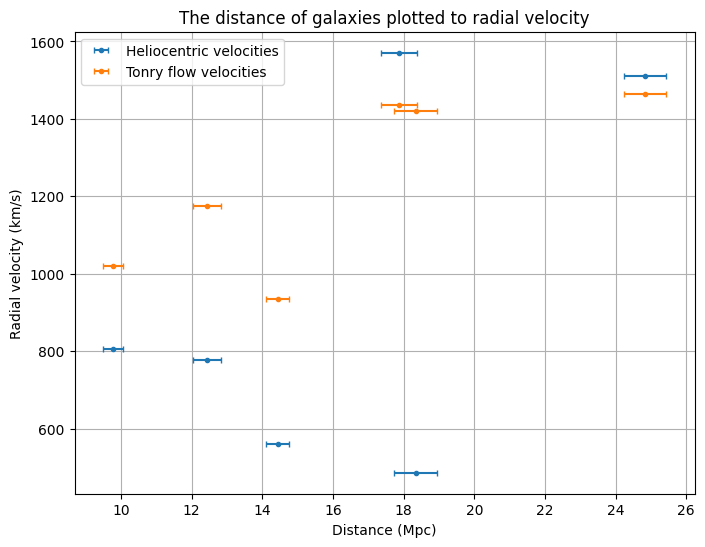

In [7]:
data_freedman = np.genfromtxt("/content/drive/MyDrive/Freedman01Table5.txt", dtype=float, skip_header=2)[1:]

data_freedman_needed = []
data_freedman_needed.append(data_freedman[3])
data_freedman_needed.append(data_freedman[5])
data_freedman_needed.append(data_freedman[9])
data_freedman_needed.append(data_freedman[11])
data_freedman_needed.append(data_freedman[12])
data_freedman_needed.append(data_freedman[15])

data_freedman_needed = np.array(data_freedman_needed)

vhel = data_freedman_needed[:,2]
vcmb = data_freedman_needed[:,4]
vvir = data_freedman_needed[:,5]
vton = data_freedman_needed[:,8]

fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vhel, fmt=".", capsize=2, label="Heliocentric velocities")
ax.errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vton, fmt=".", capsize=2, label="Tonry flow velocities")
ax.grid()
ax.legend()
ax.set_title("The distance of galaxies plotted to radial velocity")
ax.set_xlabel("Distance (Mpc)")
ax.set_ylabel("Radial velocity (km/s)")

# fig.savefig("radial_velocities_cepheid_galaxies.pdf", dpi=300, bbox_inches="tight")

# files.download("radial_velocities_cepheid_galaxies.pdf")

plt.show()

#other plot settings

# fig, ax = plt.subplots(figsize=(8,6))
# ax.errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vcmb, fmt=".", capsize=2)
# ax.grid()
# ax.set_title("The distance of galaxies plotted to relative speed to cmb")
# ax.set_xlabel("Distance (Mpc)")
# ax.set_ylabel("Radial velocity (km/s)")

# plt.show()

# fig, ax = plt.subplots(figsize=(8,6))
# ax.errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vvir, fmt=".", capsize=2)
# ax.grid()
# ax.set_title("The distance of galaxies plotted to relative speed to sun Virgocentric-corrected")
# ax.set_xlabel("Distance (Mpc)")
# ax.set_ylabel("Radial velocity (km/s)")

# plt.show()

# fig, ax = plt.subplots(figsize=(8,6))
# ax.errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vton, fmt=".", capsize=2)
# ax.grid()
# ax.set_title("The Tonry flow velocities plotted over distance")
# ax.set_xlabel("Distance (Mpc)")
# ax.set_ylabel("Radial velocity (km/s)")

# plt.show()

In [8]:
#calculate H0 for each galaxy
cepheid_H0 = vhel / (data_cepheid_dist/1e6)
cepheid_H0_err = vhel / (data_cepheid_dist/1e6)**2 * (data_cepheid_dist_err/1e6)
print(cepheid_H0, cepheid_H0_err)

#calculate H0 for each galaxy Tonry flow model
cepheid_H0_tonry = vton / (data_cepheid_dist/1e6)
cepheid_H0_tonry_err = vton / (data_cepheid_dist/1e6)**2 * (data_cepheid_dist_err/1e6)
print(cepheid_H0_tonry, cepheid_H0_tonry_err)

#calculated weighted mean and error
cepheid_H0_wmean, cepheid_H0_werr = calc_weighted_mean(cepheid_H0, cepheid_H0_err)
cepheid_H0_tonry_wmean, cepheid_H0_tonry_werr = calc_weighted_mean(cepheid_H0_tonry, cepheid_H0_tonry_err)

#calculate unweighted mean
cepheid_H0_mean = np.mean(cepheid_H0)
cepheid_H0_tonry_mean = np.mean(cepheid_H0_tonry)

#calculate scatter of the different H0 values of all galaxies
cepheid_H0_err_scatter = np.std(cepheid_H0, ddof=1)
cepheid_H0_err_scatter_mean = cepheid_H0_err_scatter / np.sqrt(len(cepheid_H0))
cepheid_H0_tonry_err_scatter = np.std(cepheid_H0_tonry, ddof=1)
cepheid_H0_tonry_err_scatter_mean = cepheid_H0_tonry_err_scatter / np.sqrt(len(cepheid_H0_tonry))

#calculate total weighted mean error with scatter
cepheid_H0_err_tot = (cepheid_H0_werr**2+cepheid_H0_err_scatter_mean**2)**0.5
cepheid_H0_tonry_err_tot = (cepheid_H0_tonry_werr**2+cepheid_H0_tonry_err_scatter_mean**2)**0.5

#calculate reduced chi value
chi2_cepheid_h0 = calc_reduced_chi2(cepheid_H0, (cepheid_H0_err**2+cepheid_H0_err_scatter**2)**0.5)
chi2_cepheid_h0_tonry = calc_reduced_chi2(cepheid_H0_tonry, (cepheid_H0_tonry_err**2+cepheid_H0_tonry_err_scatter**2)**0.5)

#vhel
#weighted mean and error
print(cepheid_H0_wmean)
print(cepheid_H0_err_tot)

#unweighted mean and error
print(cepheid_H0_mean)
print(cepheid_H0_err_scatter_mean)

#Chi^2 value
print(chi2_cepheid_h0)

print()

#Tonry
#weighted mean and error
print(cepheid_H0_tonry_wmean)
print(cepheid_H0_tonry_err_tot)

#unweighted mean and error
print(cepheid_H0_tonry_mean)
print(cepheid_H0_tonry_err_scatter_mean)

#Chi^2 value
print(chi2_cepheid_h0_tonry)

[60.88234893 38.72974523 62.59273504 82.45582997 87.90588731 26.49697237] [1.47363459 0.86674959 1.98972277 2.36673067 2.45216914 0.875242  ]
[ 58.98984206  64.84980596  94.53272966 104.4781945   80.35191227
  77.47365789] [1.42782717 1.45130164 3.00504403 2.99883886 2.24144805 2.55909235]
43.12673564644588
9.786648148443412
59.843919809749174
9.772809377405824
0.99466480331012

71.23881391808658
7.088161844797281
80.11269038999353
7.04217628709887
0.9808543343285929


372.3345754835141 102.39399658074886
2.423315491587144
214.74313849168345 102.96249707700463
0.9068094355281779

283.1010297853406 159.79664849409457
202.44431338561438 114.27095185126795


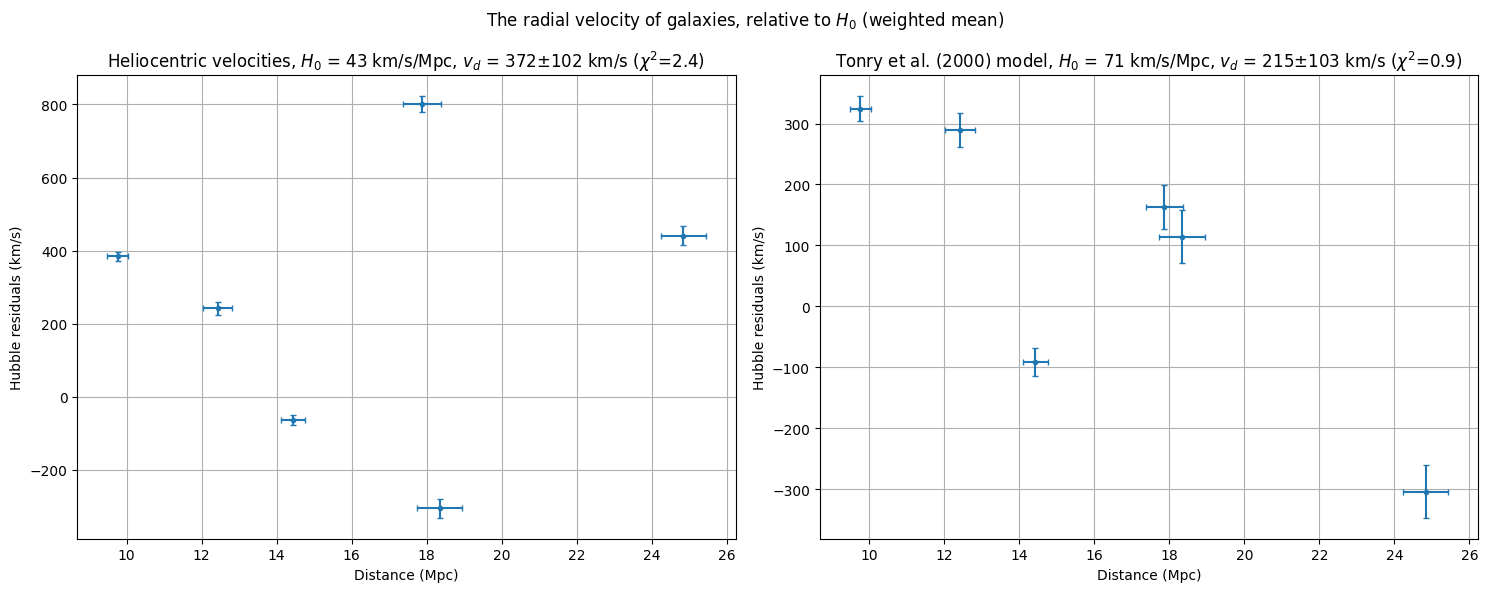

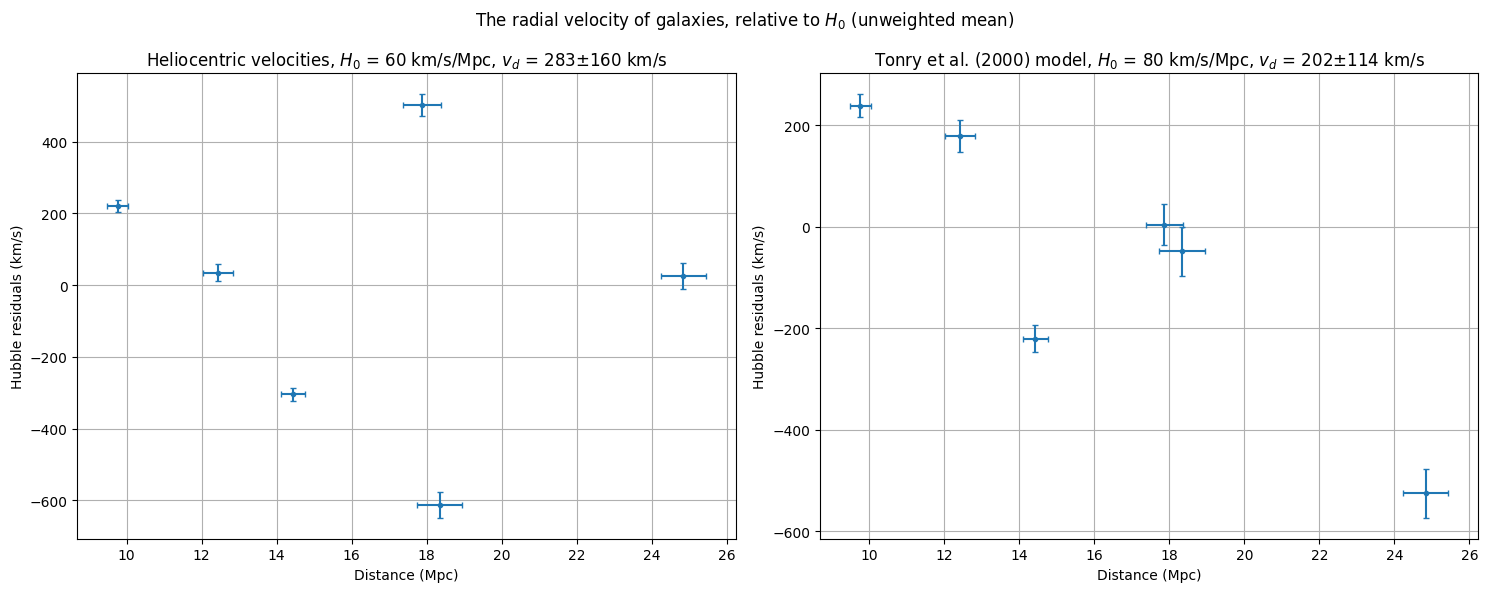

In [9]:
sigma_pec = 250 #km/s (from Tonry2000 and Giovanelli1999)

w_hubble_res_ceph_gal = vhel-cepheid_H0_wmean*data_cepheid_dist/1e6
w_hubble_res_ceph_gal_err = ((cepheid_H0_wmean*data_cepheid_dist_err/1e6)**2+sigma_pec**2)**0.5
w_hubble_res_ceph_gal_tonry = vton-cepheid_H0_tonry_wmean*data_cepheid_dist/1e6
w_hubble_res_ceph_gal_err_tonry = ((cepheid_H0_tonry_wmean*data_cepheid_dist_err/1e6)**2+sigma_pec**2)**0.5

unw_hubble_res_ceph_gal = vhel-cepheid_H0_mean*data_cepheid_dist/1e6
unw_hubble_res_ceph_gal_err = cepheid_H0_mean*data_cepheid_dist_err/1e6
unw_hubble_res_ceph_gal_tonry = vton-cepheid_H0_tonry_mean*data_cepheid_dist/1e6
unw_hubble_res_ceph_gal_err_tonry = cepheid_H0_tonry_mean*data_cepheid_dist_err/1e6

w_hubble_res_ceph_gal_disp, w_hubble_res_ceph_gal_disp_err = calc_weighted_mean(np.abs(w_hubble_res_ceph_gal), w_hubble_res_ceph_gal_err)
w_hubble_res_ceph_gal_tonry_disp, w_hubble_res_ceph_gal_disp_tonry_err = calc_weighted_mean(np.abs(w_hubble_res_ceph_gal_tonry), w_hubble_res_ceph_gal_err_tonry)

unw_hubble_res_ceph_gal_disp = np.mean(np.abs(unw_hubble_res_ceph_gal))
unw_hubble_res_ceph_gal_disp_err = np.std(unw_hubble_res_ceph_gal, ddof=1) / (len(unw_hubble_res_ceph_gal))**0.5
unw_hubble_res_ceph_gal_tonry_disp = np.mean(np.abs(unw_hubble_res_ceph_gal_tonry))
unw_hubble_res_ceph_gal_disp_tonry_err = np.std(unw_hubble_res_ceph_gal_tonry, ddof=1) / (len(unw_hubble_res_ceph_gal_tonry))**0.5

w_chi2_vd_vhel = calc_reduced_chi2(w_hubble_res_ceph_gal, w_hubble_res_ceph_gal_err)
w_chi2_vd_tonry = calc_reduced_chi2(w_hubble_res_ceph_gal_tonry, w_hubble_res_ceph_gal_err_tonry)


print(w_hubble_res_ceph_gal_disp, w_hubble_res_ceph_gal_disp_err)
print(w_chi2_vd_vhel)
print(w_hubble_res_ceph_gal_tonry_disp, w_hubble_res_ceph_gal_disp_tonry_err)
print(w_chi2_vd_tonry)
print()
print(unw_hubble_res_ceph_gal_disp, unw_hubble_res_ceph_gal_disp_err)
print(unw_hubble_res_ceph_gal_tonry_disp, unw_hubble_res_ceph_gal_disp_tonry_err)

#weighted
fig, ax = plt.subplots(1,2, figsize=(15,6))
fig.suptitle("The radial velocity of galaxies, relative to $H_0$ (weighted mean)")
ax[0].errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vhel-(cepheid_H0_wmean*data_cepheid_dist/1e6),
            yerr=(cepheid_H0_wmean*data_cepheid_dist_err/1e6), fmt=".", capsize=2)
ax[0].grid()
ax[0].set_title(rf"Heliocentric velocities, $H_0$ = {round(cepheid_H0_wmean)} km/s/Mpc, $v_d$ = {round(w_hubble_res_ceph_gal_disp)}$\pm${round(w_hubble_res_ceph_gal_disp_err)} km/s ($\chi^2$={round(w_chi2_vd_vhel,1)})")
ax[0].set_xlabel("Distance (Mpc)")
ax[0].set_ylabel("Hubble residuals (km/s)")

ax[1].errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vton-(cepheid_H0_tonry_wmean*data_cepheid_dist/1e6),
            yerr=(cepheid_H0_tonry_wmean*data_cepheid_dist_err/1e6), fmt=".", capsize=2)
ax[1].grid()
ax[1].set_title(rf"Tonry et al. (2000) model, $H_0$ = {round(cepheid_H0_tonry_wmean)} km/s/Mpc, $v_d$ = {round(w_hubble_res_ceph_gal_tonry_disp)}$\pm${round(w_hubble_res_ceph_gal_disp_tonry_err)} km/s ($\chi^2$={round(w_chi2_vd_tonry,1)})")
ax[1].set_xlabel("Distance (Mpc)")
ax[1].set_ylabel("Hubble residuals (km/s)")

plt.tight_layout()

# fig.savefig("Hubble_res_ceph_w.pdf", dpi=300, bbox_inches="tight")

# files.download("Hubble_res_ceph_w.pdf")

plt.show()

#unweigthed
fig, ax = plt.subplots(1,2, figsize=(15,6))
fig.suptitle("The radial velocity of galaxies, relative to $H_0$ (unweighted mean)")
ax[0].errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vhel-(cepheid_H0_mean*data_cepheid_dist/1e6),
            yerr=(cepheid_H0_mean*data_cepheid_dist_err/1e6), fmt=".", capsize=2)
ax[0].grid()
ax[0].set_title(rf"Heliocentric velocities, $H_0$ = {round(cepheid_H0_mean)} km/s/Mpc, $v_d$ = {round(unw_hubble_res_ceph_gal_disp)}$\pm${round(unw_hubble_res_ceph_gal_disp_err)} km/s")
ax[0].set_xlabel("Distance (Mpc)")
ax[0].set_ylabel("Hubble residuals (km/s)")

ax[1].errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vton-(cepheid_H0_tonry_mean*data_cepheid_dist/1e6),
            yerr=(cepheid_H0_tonry_mean*data_cepheid_dist_err/1e6), fmt=".", capsize=2)
ax[1].grid()
ax[1].set_title(rf"Tonry et al. (2000) model, $H_0$ = {round(cepheid_H0_tonry_mean)} km/s/Mpc, $v_d$ = {round(unw_hubble_res_ceph_gal_tonry_disp)}$\pm${round(unw_hubble_res_ceph_gal_disp_tonry_err)} km/s")
ax[1].set_xlabel("Distance (Mpc)")
ax[1].set_ylabel("Hubble residuals (km/s)")

plt.tight_layout()

# fig.savefig("Hubble_res_ceph_unw.pdf", dpi=300, bbox_inches="tight")

# files.download("Hubble_res_ceph_unw.pdf")


plt.show()


# #add velocity dispersion
# extra_yerr = 300 #km/s

# #unweighted + velocity dispersion
# fig, ax = plt.subplots(figsize=(8,6))
# ax.errorbar(x=data_cepheid_dist/1e6, xerr=data_cepheid_dist_err/1e6, y=vhel-(cepheid_H0_mean*data_cepheid_dist/1e6),
#             yerr=((cepheid_H0_mean*data_cepheid_dist_err/1e6)**2+extra_yerr**2)**0.5, fmt=".", capsize=2)
# ax.grid()
# ax.set_title(f"The radial velocity of galaxies to the sun, relative to H0 = {round(cepheid_H0_mean)} km/s/Mpc\n"
#              f"(unweighted mean), with velocity dispersion of {extra_yerr} km/s)")
# ax.set_xlabel("Distance (Mpc)")
# ax.set_ylabel("Radial velocity (km/s)")

# plt.tight_layout()
# plt.show()

#Type-Ia supernovae

0.752048839823693
-3.529397385523548 0.01151328515836247
70.12606616070111 12.923048642477978
0.3718128736999269


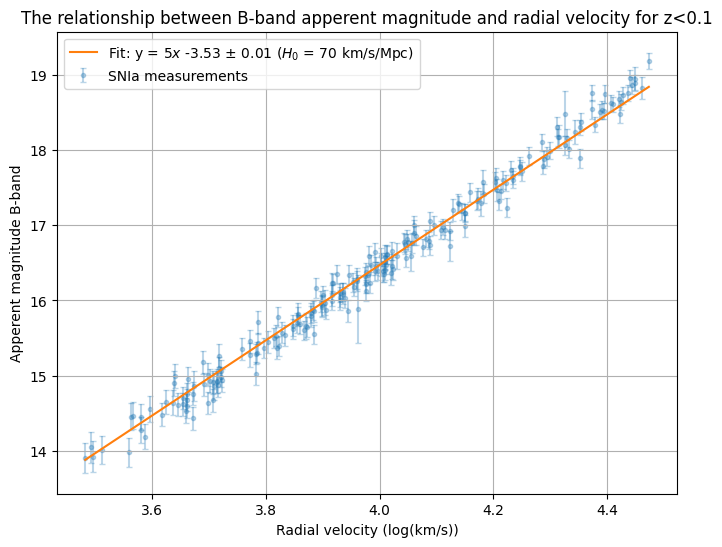

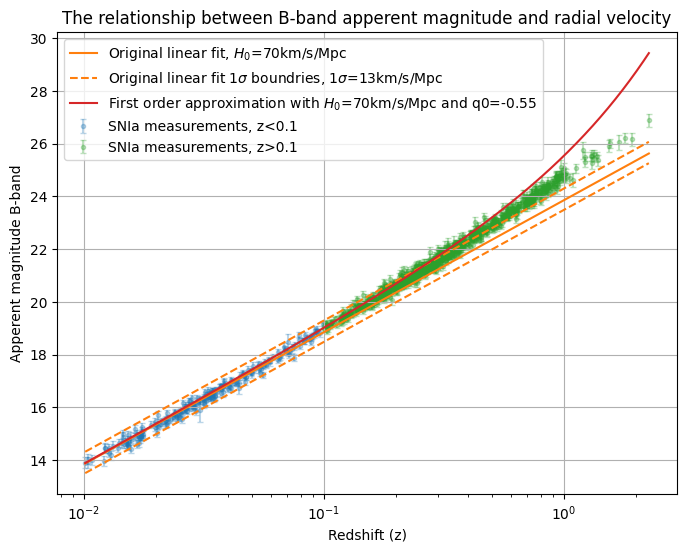

In [29]:
data_SNIa = np.genfromtxt("/content/drive/MyDrive/hlsp_ps1cosmo_panstarrs_gpc1_all_model_v1_lcparam-full.txt", dtype=float, skip_header=1)[1:]

#processing data
zhel = data_SNIa[:,2]
mb = data_SNIa[:,4]
dmb = data_SNIa[:,5]

#creating masks for z<0.1 and z>0.1
zhel_mask = zhel <= 0.1
zhel_mask2 = zhel >= 0.1

#applying masks
zhel_z01 = zhel[zhel_mask]
mb_z01 = mb[zhel_mask]
dmb_z01 = dmb[zhel_mask]

zhel_gz01 = zhel[zhel_mask2]
mb_gz01 = mb[zhel_mask2]
dmb_gz01 = dmb[zhel_mask2]

#absolute magnitudes of SNIa
M_B_SNIa = -19.3
M_B_SNIa_err = 0.4

#calculating radial velocity with redshift
rvhel_z01 = zhel_z01*cons.c.to(u.km/u.s)
rvhel_z01_log = np.log10(rvhel_z01.value)
rvhel_gz01 = zhel_gz01*cons.c.to(u.km/u.s)
rvhel_gz01_log = np.log10(rvhel_gz01.value)
rvhel = zhel*cons.c.to(u.km/u.s)
rvhel_log = np.log10(rvhel.value)

#converting to x and y etc to make it more clear
x_z01 = rvhel_z01_log
y_z01 = mb_z01

#Adding intrinsic scatter as dmb does not include this
sigma_int_z01 = 0.10  # mag (typical SN Ia value)

sigma_y_z01 = np.sqrt(dmb_z01**2 + sigma_int_z01**2)

weights_z01 = 1 / sigma_y_z01**2

#y​=ax​+b
#a=5 is required for H0 to be linear

#fitting b:
b_z01 = np.sum(weights_z01 * (y_z01 - 5*x_z01)) / np.sum(weights_z01)
b_z01_err = np.sqrt(1 / np.sum(weights_z01))

#calculating reduced chi2 value
calc_reduced_chi2_model = 5*x_z01 + b_z01
chi2 = np.sum(((y_z01 - calc_reduced_chi2_model) / sigma_y_z01)**2)
chi2_red = chi2 / (len(y_z01) - 1)

print(chi2_red)

print(b_z01, b_z01_err)

#calculating H0 value
H0_z01 = 10**((M_B_SNIa + 25 - b_z01) / 5)

#calculating H0 errors
H0_z01_err_b = (np.log(10)/5) * H0_z01 * b_z01_err
H0_z01_err_M = (np.log(10)/5) * H0_z01 * M_B_SNIa_err
H0_z01_err = (H0_z01_err_b**2 + H0_z01_err_M**2)**0.5

print(H0_z01, H0_z01_err)
print(H0_z01_err_b)

#creating x and y axes for plotting
x_fit_values = np.linspace(rvhel_z01_log.min(), rvhel_z01_log.max(), 200)
x_fit_values2 = np.linspace(rvhel_log.min(), rvhel_log.max(), 200)
y_fit_values = x_fit_values*5 + b_z01
y_fit_values2 = x_fit_values2*5 + b_z01

#plotting
fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(x=rvhel_z01_log, y=mb_z01, yerr=dmb_z01, fmt=".", capsize=2, alpha=0.3, zorder=1, label="SNIa measurements")
ax.plot(x_fit_values, y_fit_values, label=rf"Fit: y = 5$x$ {b_z01:.2f} $\pm$ {b_z01_err:.2f} ($H_0$ = {H0_z01:.0f} km/s/Mpc)")

ax.set_title("The relationship between B-band apperent magnitude and radial velocity for z<0.1")
ax.set_xlabel("Radial velocity (log(km/s))")
ax.set_ylabel("Apperent magnitude B-band")

ax.grid()
ax.legend()

# fig.savefig("mb_rv_z01.pdf", dpi=300, bbox_inches="tight")

# files.download("mb_rv_z01.pdf")

plt.show()

#calculating 1 sigma lines
# b_z01_upper_1sigma = M_B_SNIa+25-5*np.log10(H0_z01+H0_z01_err)
# b_z01_lower_1sigma = M_B_SNIa+25-5*np.log10(H0_z01-H0_z01_err)

# y_fit_values2_upper = x_fit_values2*5 + b_z01_upper_1sigma
# y_fit_values2_lower = x_fit_values2*5 + b_z01_lower_1sigma


#calculating model with first order approximation
q0 = -0.55
z_fit = np.linspace(zhel.min(), zhel.max(), 400)
y_fit_values_first_approx = (M_B_SNIa+25 + 5*np.log10(cons.c.to(u.km/u.s).value*z_fit/H0_z01) + (5/np.log(10))*((1-q0)/2)*z_fit)

y_fit_H0_linear = (M_B_SNIa + 25 + 5*np.log10(cons.c.to(u.km/u.s).value * z_fit / H0_z01))
y_fit_H0_linear_upper = (M_B_SNIa + 25 + 5*np.log10(cons.c.to(u.km/u.s).value * z_fit / (H0_z01+H0_z01_err)))
y_fit_H0_linear_lower = (M_B_SNIa + 25 + 5*np.log10(cons.c.to(u.km/u.s).value * z_fit / (H0_z01-H0_z01_err)))


#plotting model with all SNIa data with first order approximation
fig, ax = plt.subplots(figsize=(8,6))
ax.errorbar(x=zhel_z01, y=mb_z01, yerr=dmb_z01, fmt=".", capsize=2, alpha=0.3, zorder=1, label="SNIa measurements, z<0.1")
ax.errorbar(x=zhel_gz01, y=mb_gz01, yerr=dmb_gz01, fmt=".", capsize=2, alpha=0.3, zorder=1, label="SNIa measurements, z>0.1", color="tab:green")
ax.plot(z_fit, y_fit_H0_linear, label=rf"Original linear fit, $H_0$={round(H0_z01)}km/s/Mpc", color="tab:orange")
ax.plot(z_fit, y_fit_H0_linear_upper, "--", label=rf"Original linear fit 1$\sigma$ boundries, 1$\sigma$={round(H0_z01_err)}km/s/Mpc", color="tab:orange")
ax.plot(z_fit, y_fit_H0_linear_lower, "--", color="tab:orange")
ax.plot(z_fit, y_fit_values_first_approx, color="tab:red", label=f"First order approximation with $H_0$={round(H0_z01)}km/s/Mpc and q0={q0}")

ax.set_title("The relationship between B-band apperent magnitude and radial velocity")
ax.set_xlabel("Redshift (z)")
ax.set_ylabel("Apperent magnitude B-band")
ax.set_xscale('log')
ax.grid()
ax.legend()

# fig.savefig("mb_z_all.pdf", dpi=300, bbox_inches="tight")

# files.download("mb_z_all.pdf")

plt.show()


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

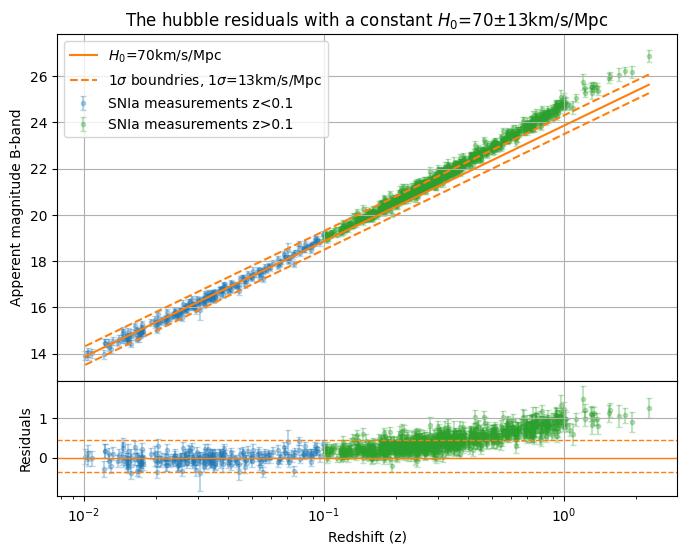

In [26]:
from matplotlib import gridspec

def predict_SNIa_mB(H0_value, z_value, abs_mag_SNIa):
    """
    This function calculates the apperent magnitude of SNIa with redshift used
    for hubble residuals
    """

    #calculating distance corresponding to z and H0 values
    distance_pc_eq = z_value*cons.c.to(u.km/u.s)/(H0_value*u.km/u.s/u.Mpc).to(u.km/u.s/u.pc)

    #converting this to distance modulus
    distance_mod_eq = 5*np.log10(distance_pc_eq.to(u.pc).value) - 5

    #converting this to SNIa apperent magnitude
    predicted_SNIa_mB = abs_mag_SNIa + distance_mod_eq

    return predicted_SNIa_mB

#calculate the values to subtract for hubble residuals
predicted_SNIa_mB = predict_SNIa_mB(H0_z01, zhel, M_B_SNIa)
predicted_SNIa_mB_upper = predict_SNIa_mB(H0_z01+H0_z01_err, zhel, M_B_SNIa)
predicted_SNIa_mB_lower = predict_SNIa_mB(H0_z01-H0_z01_err, zhel, M_B_SNIa)

#calculating hubble residuals
hubble_res_SNIa_lin = mb - predicted_SNIa_mB

#calculating 1 sigma hubble residual boundries
upper_hubbel_res = np.mean(predicted_SNIa_mB_upper-predicted_SNIa_mB)
lower_hubbel_res = np.mean(predicted_SNIa_mB_lower-predicted_SNIa_mB)

#predicting magnitudes of redshift models
x_fit_values_z = np.linspace(zhel.min(), zhel.max(), 200)
y_fit_values_z = predict_SNIa_mB(H0_z01, x_fit_values_z, M_B_SNIa)
y_fit_values_z_upper = predict_SNIa_mB(H0_z01+H0_z01_err, x_fit_values_z, M_B_SNIa)
y_fit_values_z_lower = predict_SNIa_mB(H0_z01-H0_z01_err, x_fit_values_z, M_B_SNIa)

#plotting
fig=plt.figure(figsize=(8,6))
plt.style.use('default')
gs = gridspec.GridSpec(2, 1, height_ratios=[3,1], hspace=0.0)

ax1 = plt.subplot(gs[0])
ax1.set_title(rf"The hubble residuals with a constant $H_0$={round(H0_z01)}$\pm${round(H0_z01_err)}km/s/Mpc")
ax1.errorbar(x=zhel[zhel_mask], y=mb[zhel_mask], yerr=dmb[zhel_mask], fmt=".", capsize=2, alpha=0.3, zorder=1, label="SNIa measurements z<0.1")
ax1.errorbar(x=zhel[zhel_mask2], y=mb[zhel_mask2], yerr=dmb[zhel_mask2], fmt=".", capsize=2, alpha=0.3, zorder=1, color="tab:green", label="SNIa measurements z>0.1")
ax1.plot(x_fit_values_z, y_fit_values_z, zorder=2, color="tab:orange", label=f"$H_0$={round(H0_z01)}km/s/Mpc")
ax1.plot(x_fit_values_z, y_fit_values_z_upper, "--", zorder=2, color="tab:orange", label=rf"1$\sigma$ boundries, 1$\sigma$={round(H0_z01_err)}km/s/Mpc")
ax1.plot(x_fit_values_z, y_fit_values_z_lower, "--", zorder=2, color="tab:orange")
ax1.set_ylabel("Apperent magnitude B-band")
ax1.set_xscale('log')
ax1.legend()
ax1.grid()

ax2 = plt.subplot(gs[1])
ax2.errorbar(x=zhel[zhel_mask], y=hubble_res_SNIa_lin[zhel_mask], yerr=dmb[zhel_mask], fmt=".", capsize=2, alpha=0.3, zorder=1, label="SNIa measurements")
ax2.errorbar(x=zhel[zhel_mask2], y=hubble_res_SNIa_lin[zhel_mask2], yerr=dmb[zhel_mask2], fmt=".", capsize=2, alpha=0.3, zorder=1, color="tab:green", label="SNIa measurements")
ax2.axhline(0, color='tab:orange', linestyle='-', linewidth=1, zorder=2)
ax2.axhline(upper_hubbel_res, color='tab:orange', linestyle='--', linewidth=1, zorder=2)
ax2.axhline(lower_hubbel_res, color='tab:orange', linestyle='--', linewidth=1, zorder=2)
ax2.set_xlabel("Redshift (z)")
ax2.set_ylabel("Residuals")
ax2.set_xscale('log')
ax2.grid()

# fig.savefig("hubble_res_z_all.pdf", dpi=300, bbox_inches="tight")

# files.download("hubble_res_z_all.pdf")

plt.show()